<a href="https://colab.research.google.com/github/MariamKhaled741/Data-computation-project/blob/main/Data_computation_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [23]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    normalized_mutual_info_score
)

%matplotlib inline
sns.set_theme(style="whitegrid")

#Connect to GitHub and drive

In [24]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Data-computation-project

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Data-computation-project


In [25]:
df = pd.read_csv('data/hotel_bookings.csv')

In [26]:
!ls

app.py	Data_computation_project.ipynb	README.md
data	hotel_model_package.pkl


In [61]:
# 1. مسح الملفات بالقوة من الـ Git ومن المجلد
!git rm -f app.py
!git rm -f hotel_model_package.pkl
!git rm -f requirements.txt

# 2. تسجيل المسح
!git commit -m "Force remove files to reset project"

# 3. الرفع لجيت هاب
!git push origin main --force

rm 'app.py'
rm 'hotel_model_package.pkl'
rm 'requirements.txt'
[main 0b5e7f4] Force remove files to reset project
 3 files changed, 90 deletions(-)
 delete mode 100644 app.py
 delete mode 100644 hotel_model_package.pkl
 delete mode 100644 requirements.txt
Enumerating objects: 3, done.
Counting objects: 100% (3/3), done.
Delta compression using up to 2 threads
Compressing objects: 100% (2/2), done.
Writing objects: 100% (2/2), 252 bytes | 31.00 KiB/s, done.
Total 2 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/MariamKhaled741/Data-computation-project.git
   8f633f0..0b5e7f4  main -> main


#Dataset Overview

In [27]:

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

print("--- Dataset Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
display(df.describe())

print(f"\nDataset Shape: {df.shape}")

print("\n--- First 5 Rows ---")
display(df.head())

"""# 2. Preliminary Cleaning (Quasi-constant Features)"""

print("\n--- Babies Column Distribution (%) ---")
babies_dist = df['babies'].value_counts(normalize=True) * 100
print(babies_dist)



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



Dataset Shape: (119390, 32)

--- First 5 Rows ---


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



--- Babies Column Distribution (%) ---
babies
0     99.231929
1      0.753832
2      0.012564
10     0.000838
9      0.000838
Name: proportion, dtype: float64


#Data Cleaning

In [28]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date_month'] = df['arrival_date_month'].map(month_map)

df['company'] = df['company'].fillna('No_Company')
df['agent'] = df['agent'].fillna('No_agent')
df['children'] = df['children'].fillna(0)


df['company_cancel_rate'] = df.groupby('company')['is_canceled'].transform('mean')
df['agent_cancel_rate'] = df.groupby('agent')['is_canceled'].transform('mean')

df['room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

df['has_parking'] = (df['required_car_parking_spaces'] > 0).astype(int)


df = df.drop(['babies', 'agent', 'company'], axis=1)


X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

country_map = pd.concat([X_train, y_train], axis=1).groupby('country')['is_canceled'].mean()
X_train['country_cancel_rate'] = X_train['country'].map(country_map)
X_test['country_cancel_rate'] = X_test['country'].map(country_map).fillna(y_train.mean())

X_train = X_train.drop('country', axis=1)
X_test = X_test.drop('country', axis=1)

def fix_adr(X):
    X = X.copy()
    if 'adr' in X.columns:
        X['adr'] = X['adr'].clip(lower=0)
    return X

print("--- Cleaning & Splitting Completed ---")

--- Cleaning & Splitting Completed ---


#EDA

/tmp/ipykernel_8635/3843001606.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_rate, x='arrival_date_month', y='is_canceled', ax=axes[i], palette='viridis')
/tmp/ipykernel_8635/3843001606.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_rate, x='arrival_date_month', y='is_canceled', ax=axes[i], palette='viridis')
/tmp/ipykernel_8635/3843001606.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_rate, x='arrival_date_month', y='is_canceled', ax=axes[i], palette='viridis')


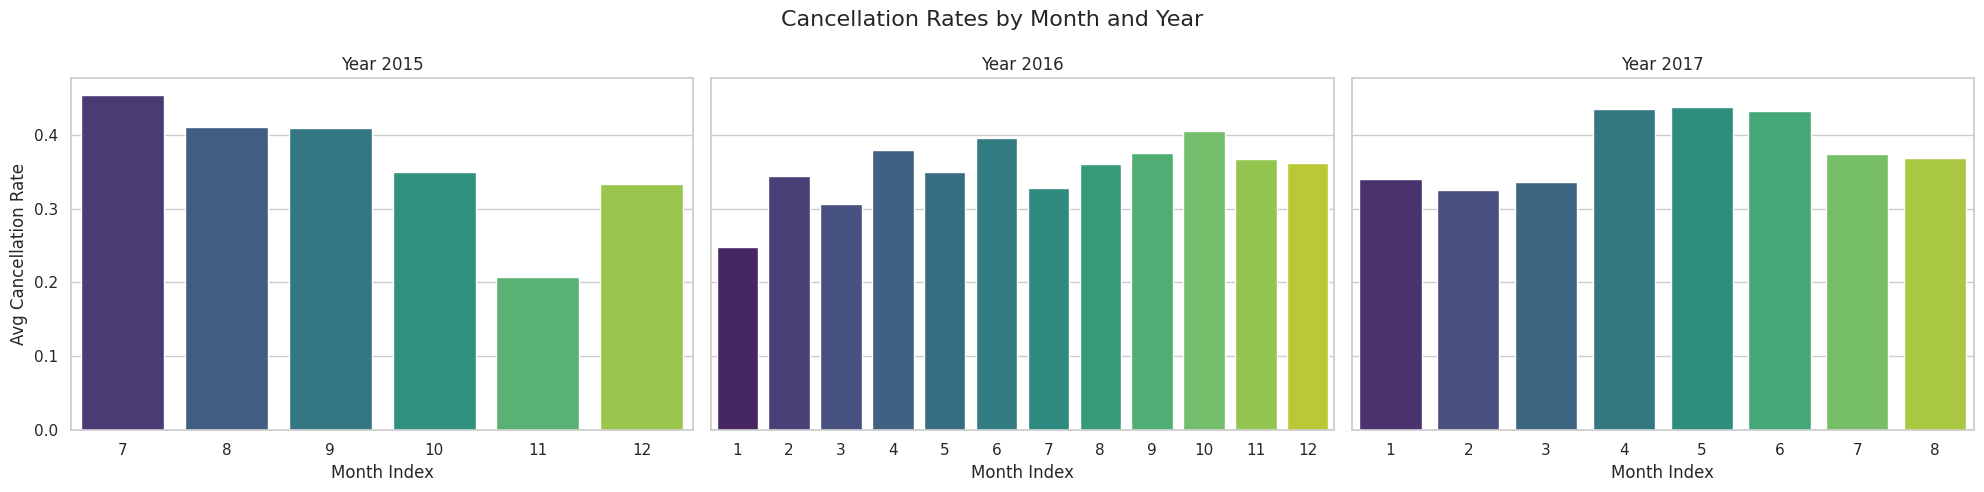

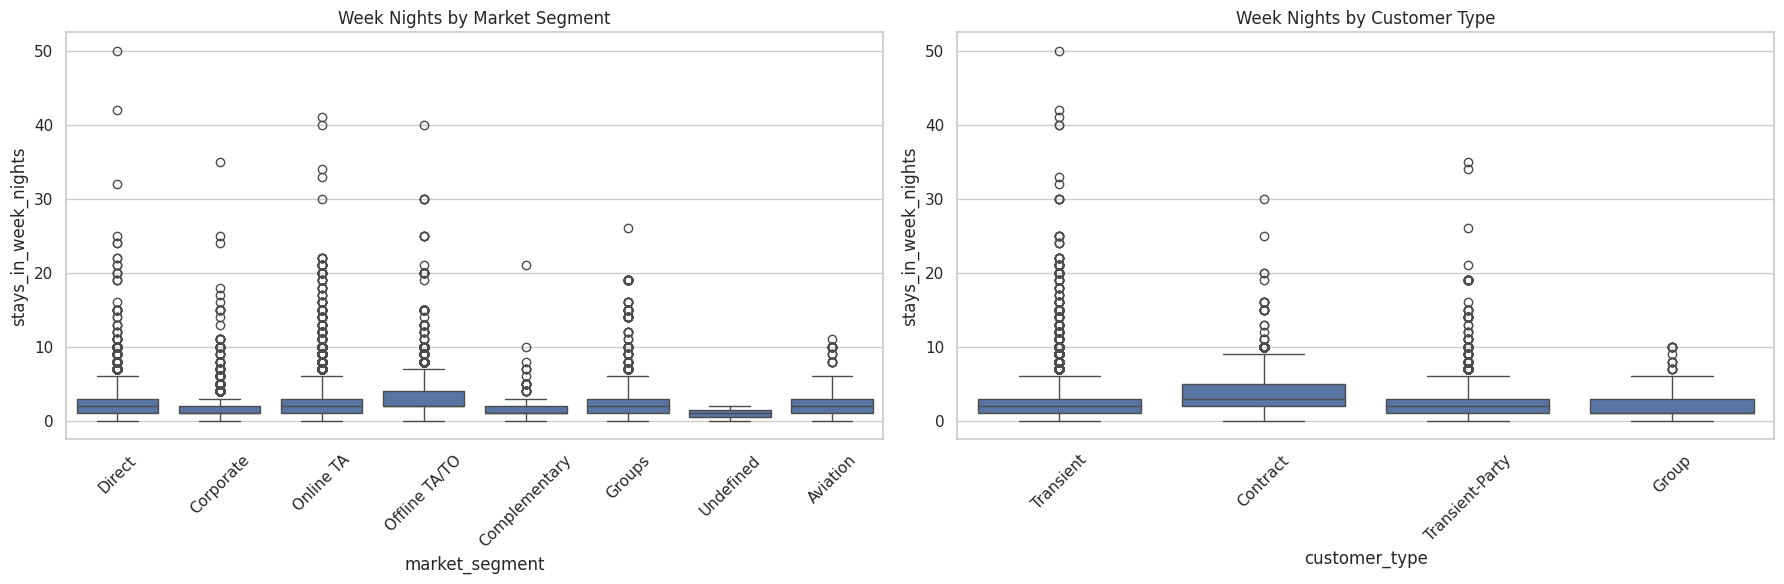

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


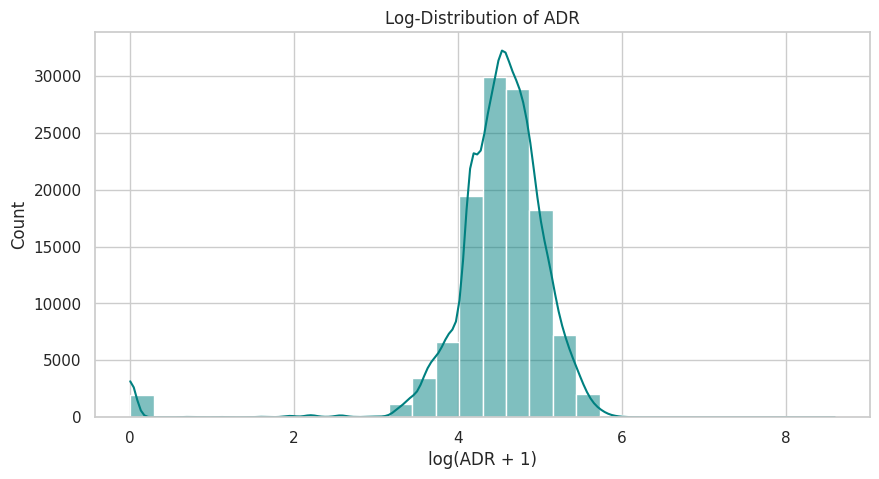

/tmp/ipykernel_8635/3843001606.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='has_parking', y='is_canceled', ax=ax2, palette='pastel')


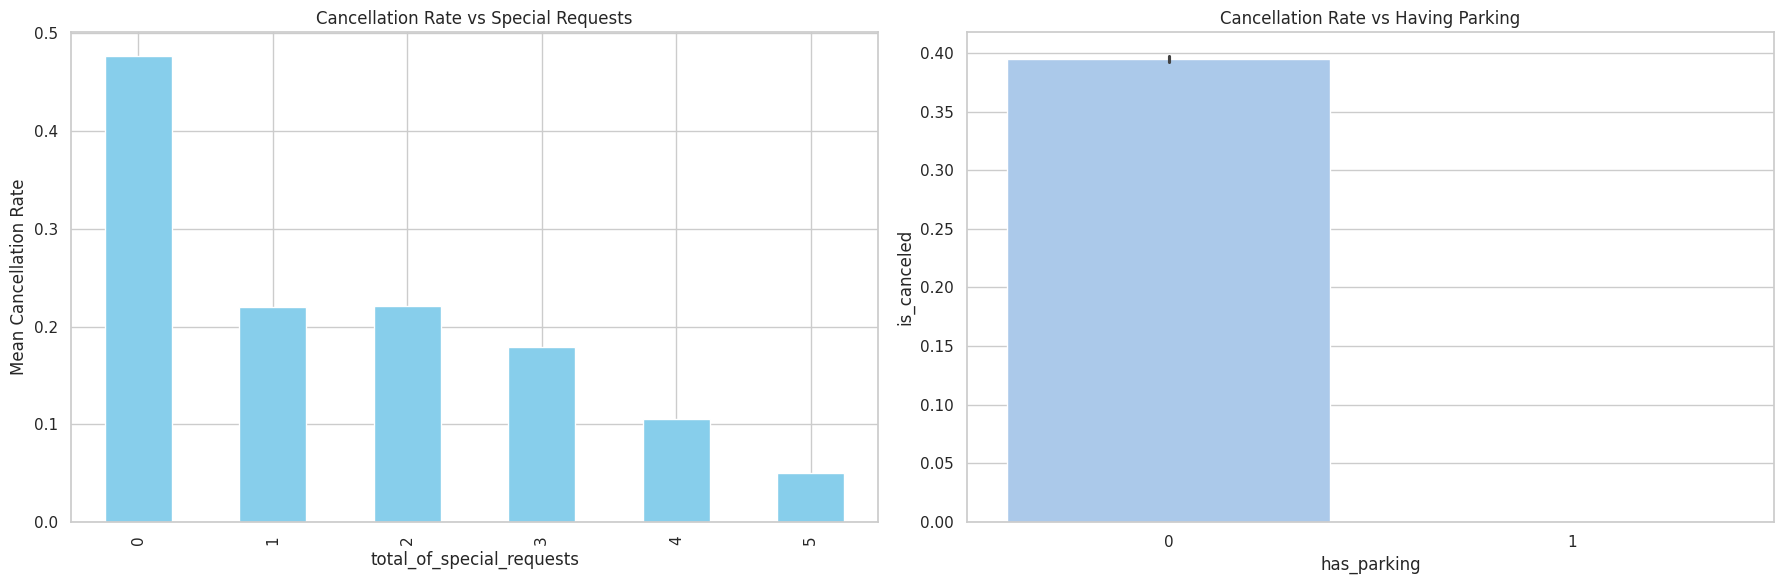

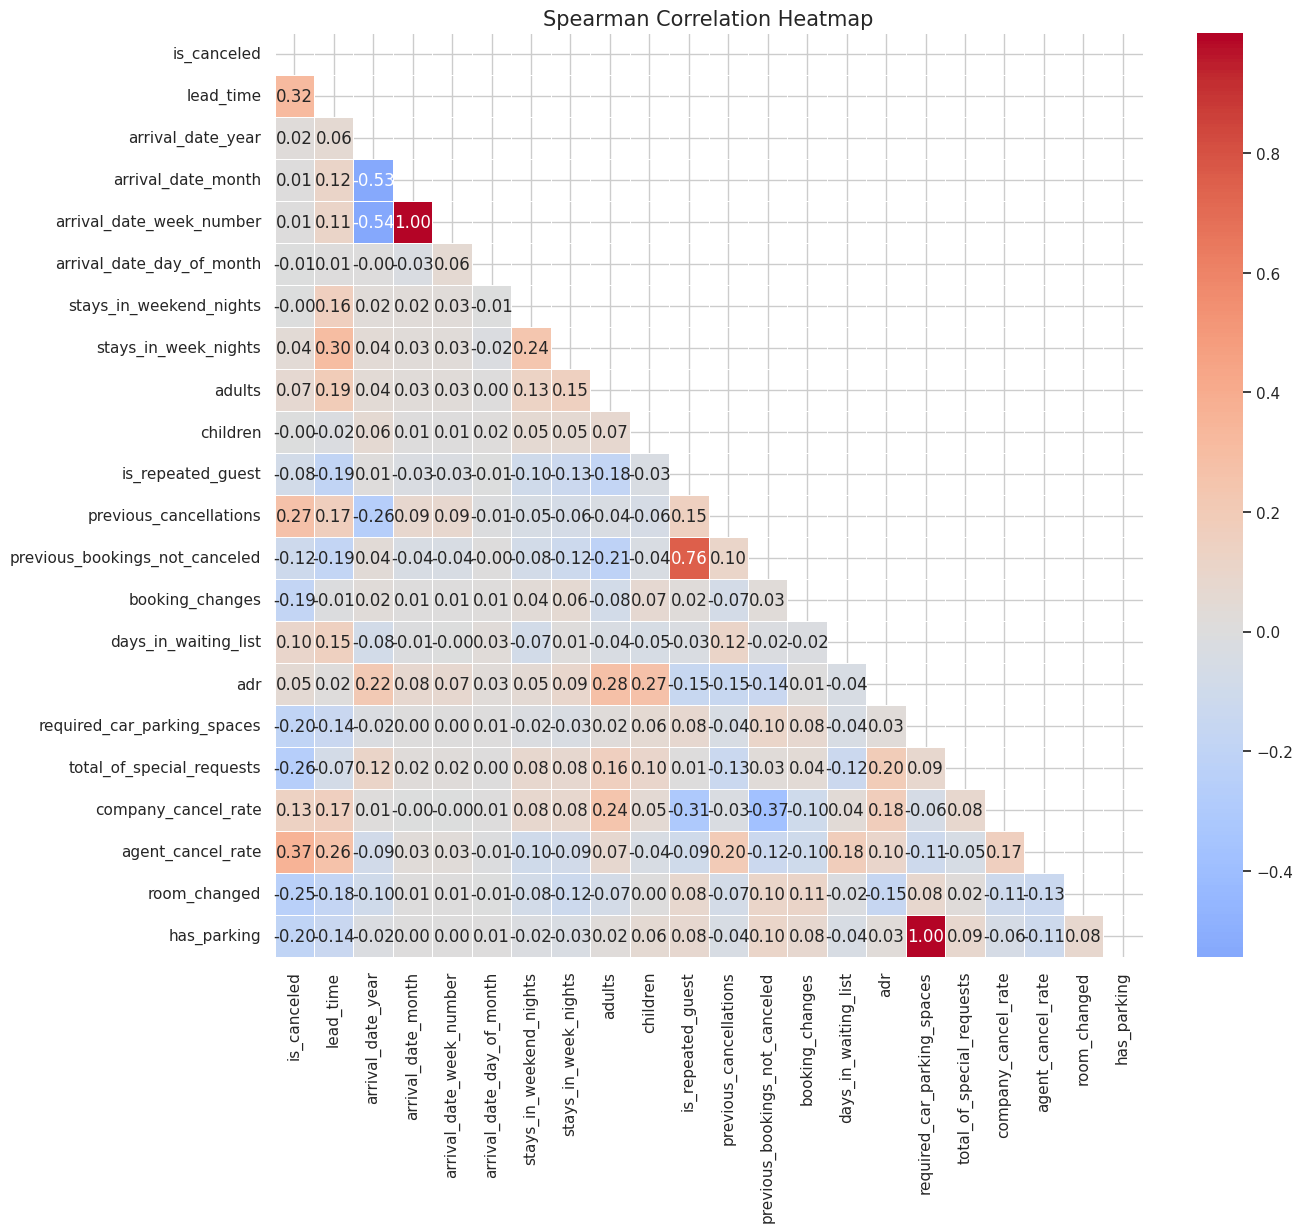

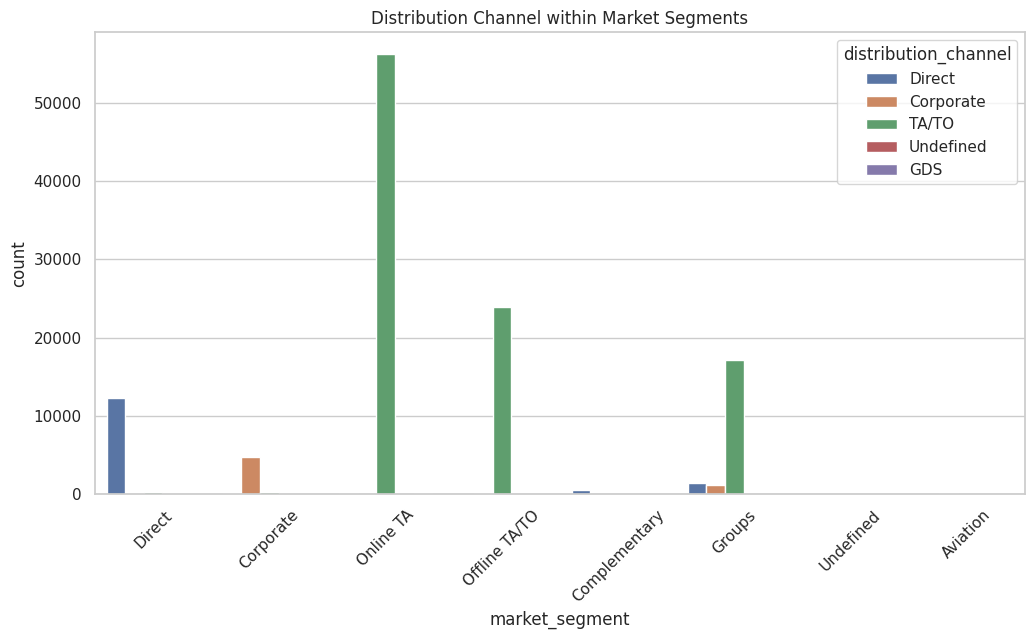

/tmp/ipykernel_8635/3843001606.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='Set2')


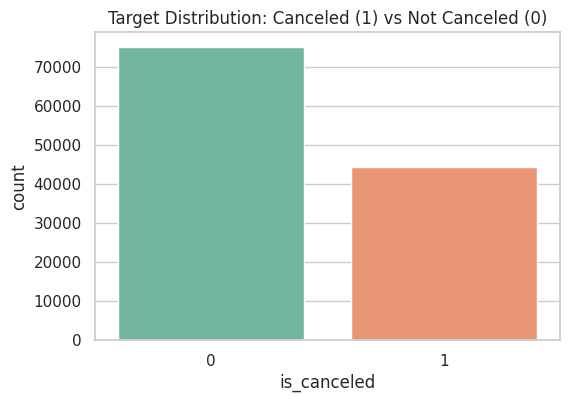

Normalized Mutual Information (Country vs Is_Canceled): 0.0432


In [29]:

years = sorted(df['arrival_date_year'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(20, 5), sharey=True)

for i, year in enumerate(years):
    data = df[df['arrival_date_year'] == year]
    monthly_rate = data.groupby('arrival_date_month')['is_canceled'].mean().reset_index()
    sns.barplot(data=monthly_rate, x='arrival_date_month', y='is_canceled', ax=axes[i], palette='viridis')
    axes[i].set_title(f"Year {year}")
    axes[i].set_xlabel("Month Index")
    axes[i].set_ylabel("Avg Cancellation Rate")

plt.suptitle("Cancellation Rates by Month and Year", fontsize=16)
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df, x='market_segment', y='stays_in_week_nights', ax=ax1)
ax1.set_title('Week Nights by Market Segment')
ax1.tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='customer_type', y='stays_in_week_nights', ax=ax2)
ax2.set_title('Week Nights by Customer Type')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df['adr']), bins=30, kde=True, color='teal')
plt.title('Log-Distribution of ADR')
plt.xlabel('log(ADR + 1)')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

df.groupby('total_of_special_requests')['is_canceled'].mean().plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Cancellation Rate vs Special Requests')
ax1.set_ylabel('Mean Cancellation Rate')

sns.barplot(data=df, x='has_parking', y='is_canceled', ax=ax2, palette='pastel')
ax2.set_title('Cancellation Rate vs Having Parking')

plt.tight_layout()
plt.show()

numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Spearman Correlation Heatmap", fontsize=15)
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x='market_segment', hue='distribution_channel', ax=ax)
plt.title('Distribution Channel within Market Segments')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df, palette='Set2')
plt.title('Target Distribution: Canceled (1) vs Not Canceled (0)')
plt.show()

country_filled = df['country'].fillna('Unknown')
nmi_country = normalized_mutual_info_score(country_filled, df['is_canceled'])
print(f"Normalized Mutual Information (Country vs Is_Canceled): {nmi_country:.4f}")

#Feature Selection (Lasso), Dimensionality Reduction (PCA)

--- Feature Selection Results ---
Number of original features: 71
Number of features selected after Lasso: 29
Excluded features (Coeff = 0): 42


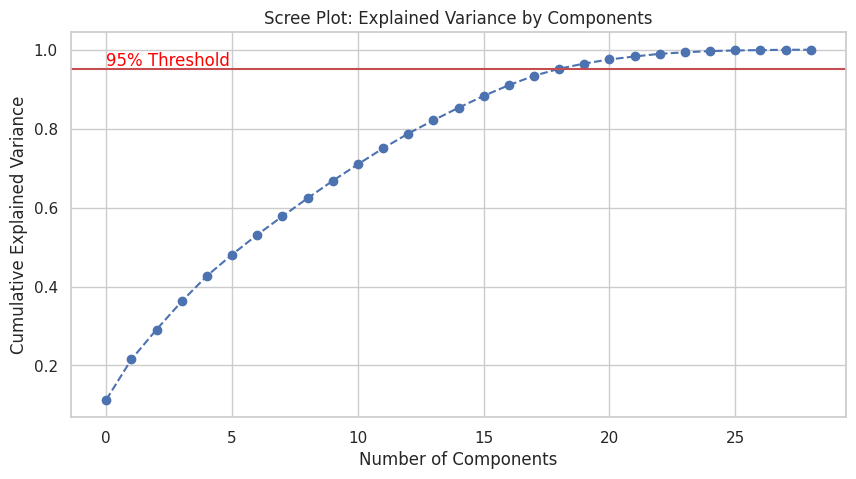


--- PCA Results ---
Data size after PCA: (95512, 19)
Number of components selected: 19

NMI (Booking Changes vs Is Canceled): 0.0326


In [30]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = ['market_segment', 'distribution_channel', 'customer_type', 'hotel',
            'deposit_type', 'meal', 'reserved_room_type', 'assigned_room_type']

numeric_pipeline = Pipeline(steps=[
    ('fix_adr', FunctionTransformer(fix_adr)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols)
    ]
)

X_train_trans = preprocess.fit_transform(X_train)
X_test_trans = preprocess.transform(X_test)

cat_features_names = list(
    preprocess.named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_cols)
)
all_features_names = np.array(num_cols + cat_features_names)

logreg = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, C=0.01)
logreg.fit(X_train_trans, y_train)

mask = logreg.coef_[0] != 0
X_train_selected = X_train_trans[:, mask]
X_test_selected = X_test_trans[:, mask]

selected_features = all_features_names[mask]
dropped_features = all_features_names[~mask]
print(f"--- Feature Selection Results ---")
print(f"Number of original features: {len(all_features_names)}")
print(f"Number of features selected after Lasso: {len(selected_features)}")
print(f"Excluded features (Coeff = 0): {len(dropped_features)}")


pca_full = PCA().fit(X_train_selected)

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0, 0.96, '95% Threshold', color='red', fontsize=12)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: Explained Variance by Components')
plt.grid(True)
plt.show()

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

print(f"\n--- PCA Results ---")
print(f"Data size after PCA: {X_train_pca.shape}")
print(f"Number of components selected: {pca.n_components_}")

n_booking = normalized_mutual_info_score(df['booking_changes'], df['is_canceled'])
print(f"\nNMI (Booking Changes vs Is Canceled): {n_booking:.4f}")

#SVM and pipeline

Searching for the best parameters...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters found: {'kernel': 'rbf', 'gamma': 'auto', 'C': 10}

Final training on 20,000 records is underway... Please wait a moment.

--- Final Model Report ---
              precision    recall  f1-score   support

           0       0.87      0.91      0.89     15033
           1       0.83      0.77      0.80      8845

    accuracy                           0.86     23878
   macro avg       0.85      0.84      0.84     23878
weighted avg       0.85      0.86      0.85     23878



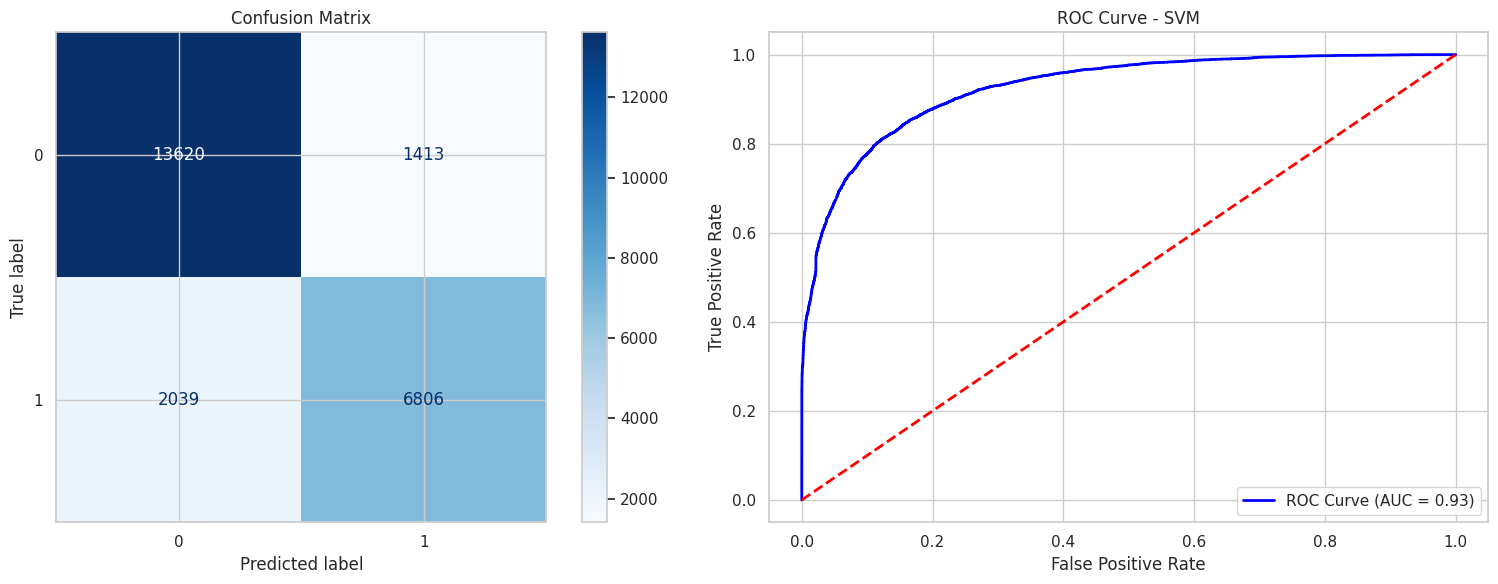

Final AUC Score: 0.9255


In [31]:
print("Searching for the best parameters...")
param_grid = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01]
}

grid = RandomizedSearchCV(
    SVC(),
    param_grid,
    n_iter=5,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
grid.fit(X_train_pca[:10000], y_train[:10000])

print(f"Best Parameters found: {grid.best_params_}")


X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_pca, y_train,
    train_size=20000,
    stratify=y_train,
    random_state=42
)

print("\nFinal training on 20,000 records is underway... Please wait a moment.")
best_model = SVC(
    kernel=grid.best_params_['kernel'],
    gamma=grid.best_params_['gamma'],
    C=grid.best_params_['C']
)
best_model.fit(X_train_sub, y_train_sub)

y_pred = best_model.predict(X_test_pca)

print("\n--- Final Model Report ---")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix")

y_scores = best_model.decision_function(X_test_pca)
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve - SVM')
ax[1].legend(loc='lower right')
ax[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Final AUC Score: {roc_auc:.4f}")

#Deployment

In [68]:
import joblib

# تجميع كل الأدوات اللي الـ App محتاجها في قاموس واحد
data_package = {
    'model': best_model,             # اسم الموديل في الكود بتاعك
    'preprocessor': preprocessor,      # تأكدي إن ده اسم الـ Pipeline/ColumnTransformer
    'pca': pca,                        # اسم الـ PCA اللي استخدمتيه
    'selected_mask': selected_mask,    # القناع بتاع الـ Feature Selection
    'num_cols': num_cols               # قائمة الأعمدة الرقمية
}

# حفظ الملف
joblib.dump(data_package, 'hotel_model_package.pkl')

print("✅ تم حفظ الملف بنجاح باسم: hotel_model_package.pkl")

NameError: name 'preprocessor' is not defined

In [64]:
requirements = """
streamlit
pandas
joblib
numpy
scikit-learn==1.3.2
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

print(" requirements.txt created successfully!")

 requirements.txt created successfully!


In [65]:
app_code = """
import streamlit as st
import pandas as pd
import joblib
import numpy as np
import sys
import types

def fix_adr(X):
    X = X.copy()
    if 'adr' in X.columns:
        X['adr'] = pd.to_numeric(X['adr'], errors='coerce').fillna(0)
        X['adr'] = X['adr'].apply(lambda x: 0 if x < 0 else x)
    return X

import __main__
__main__.fix_adr = fix_adr
sys.modules['__main__'].fix_adr = fix_adr

st.set_page_config(page_title="Hotel Booking Predictor", layout="wide")
st.title(" Hotel Reservation Cancellation Predictor")
st.markdown("---")

@st.cache_resource
def load_all_assets():
    return joblib.load('hotel_model_package.pkl')

try:
    data_pkg = load_all_assets()
except Exception as e:
    st.error(f" Error loading model: {e}")
    st.stop()

col1, col2, col3 = st.columns(3)

with col1:
    st.subheader("📋 Booking Info")
    lead_time = st.number_input("Lead Time (Days)", min_value=0, value=30)
    market_segment = st.selectbox("Market Segment", ['Online TA', 'Offline TA/TO', 'Groups', 'Direct', 'Corporate'])
    deposit_type = st.selectbox("Deposit Type", ['No Deposit', 'Non Refund', 'Refundable'])

with col2:
    st.subheader(" Financials")
    adr = st.number_input("Average Daily Rate (ADR)", min_value=0.0, value=120.0)
    customer_type = st.selectbox("Customer Type", ['Transient', 'Contract', 'Transient-Party', 'Group'])
    total_special_requests = st.slider("Special Requests", 0, 5, 1)

with col3:
    st.subheader(" Logistics")
    hotel = st.selectbox("Hotel Type", ["City Hotel", "Resort Hotel"])
    distribution_channel = st.selectbox("Distribution Channel", ['TA/TO', 'Direct', 'Corporate', 'GDS'])
    has_parking = st.selectbox("Required Parking?", ["No", "Yes"])

st.markdown("---")

if st.button("Predict Cancellation Status", use_container_width=True):
    input_dict = {
        'lead_time': lead_time, 'adr': adr, 'total_of_special_requests': total_special_requests,
        'has_parking': 1 if has_parking == "Yes" else 0, 'market_segment': market_segment,
        'deposit_type': deposit_type, 'customer_type': customer_type, 'hotel': hotel,
        'distribution_channel': distribution_channel, 'company_cancel_rate': 0.15,
        'meal': 'BB', 'reserved_room_type': 'A', 'assigned_room_type': 'A',
        'arrival_date_month': 'July', 'arrival_date_year': 2017, 'arrival_date_week_number': 27,
        'arrival_date_day_of_month': 1, 'stays_in_weekend_nights': 0, 'stays_in_week_nights': 2,
        'adults': 2, 'children': 0, 'babies': 0, 'is_repeated_guest': 0,
        'previous_cancellations': 0, 'previous_bookings_not_canceled': 0,
        'booking_changes': 0, 'days_in_waiting_list': 0, 'required_car_parking_spaces': 0,
        'total_nights': 2, 'total_people': 2, 'room_changed': 0,
        'agent_cancel_rate': 0.2, 'country_cancel_rate': 0.2
    }

    input_df = pd.DataFrame([input_dict])

    for col in input_df.columns:
        if col in data_pkg['num_cols']:
            input_df[col] = pd.to_numeric(input_df[col], errors='coerce')
        else:
            input_df[col] = input_df[col].astype(object)

    try:
        processed = data_pkg['preprocessor'].transform(input_df)
        selected = processed[:, data_pkg['selected_mask']]
        compressed = data_pkg['pca'].transform(selected)
        prediction = data_pkg['model'].predict(compressed)

        if prediction[0] == 1:
            st.error("### ⚠️ Prediction: CANCELED")
        else:
            st.success("###  Prediction: NOT CANCELED")
            st.balloons()

    except Exception as e:
        st.error(f"Error during prediction: {e}")
"""

with open('app.py', 'w') as f:
    f.write(app_code.strip())

print(" app.py created successfully!")

 app.py created successfully!


In [66]:
!git add app.py requirements.txt hotel_model_package.pkl
!git commit -m "Deploy fresh version with fixed dependencies"
!git push origin main --force

print("All files are now on GitHub! Go to Streamlit Cloud to deploy.")

fatal: pathspec 'hotel_model_package.pkl' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	app.py
	requirements.txt

nothing added to commit but untracked files present (use "git add" to track)
Everything up-to-date
All files are now on GitHub! Go to Streamlit Cloud to deploy.
